<a href="https://colab.research.google.com/github/traviswheeler/CompBioAsia/blob/main/2-CompBioAsia_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# REAL Deep Learning
We are now ready to do real deep learning. Here you're going to build your own models to try to solve real problems. I'll take care of the optimization code so you can focus on the fun stuff. Your goal is to get the largest testing accuracy you can!

## MNIST
The first thing we're going to try to learn is hand written digits. First we'll download the MNIST dataset (a dataset of hand written digits). Then we'll build a a model and train that model on MNIST. Finally we'll test our model and try to figure out how we can make our model better.

#### Setup

---

    Load libraries, download data, build some helper functions.  You can safely ignore this (until you want to dig into the details later)

In [4]:
!pip install -q graphviz # needed on Colab (the draw_* helpers use it)
import torch # The big pytorch library
from torch import nn # Pytorch's neural network library
import torch.nn.functional as F # Some useful helper functions

# Torchvision will let us load up the MNIST dataset EZ PZ
from torchvision import datasets, transforms 

import matplotlib.pyplot as plt # Matplotlib for visualization

# ====================================================================
# This cell grabs MNIST and loads it into tensors for us

transform = transforms.Compose([
                                transforms.ToTensor(),
                                transforms.Normalize(0.1307, 0.3081)
])

batch_size = 128

train_data = datasets.MNIST('../data', train=True, download=True,
                       transform=transform)
test_data = datasets.MNIST('../data', train=False, download=True,
                       transform=transform)


train_loader = torch.utils.data.DataLoader(train_data, batch_size=len(train_data), shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=len(test_data), shuffle=True)

x_train, y_train = next(iter(train_loader))
x_train = x_train.squeeze()
y_train = F.one_hot(y_train)
y_train = y_train.float()

x_small = x_train[0:500]   # limit to 500 training entries
y_small = y_train[0:500]   # limit to 500 training entries
#y_small = F.one_hot(y_small)
y_small = y_small.float()

x_test, y_test = next(iter(test_loader))
x_test = x_test.squeeze()
y_test = F.one_hot(y_test)
y_test = y_test.float()


print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)

print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

# ====================================================================
# --- Prep two 2-class datasets, so we can warm up on easy binary problems ---
# We reuse the MNIST tensors loaded above. y_train / y_test are one-hot over
# 10 classes, so the original digit label is just the argmax.
train_labels = y_train.argmax(dim=-1)
test_labels  = y_test.argmax(dim=-1)

def make_binary(digit_a, digit_b):
    """Build a 2-class dataset containing only digit_a and digit_b.
    Column 0 of the one-hot label = digit_a, column 1 = digit_b."""
    tr_mask = (train_labels == digit_a) | (train_labels == digit_b)
    te_mask = (test_labels  == digit_a) | (test_labels  == digit_b)
    x_tr = x_train[tr_mask]
    x_te = x_test[te_mask]
    # map digit_a -> 0, digit_b -> 1, then one-hot into 2 columns
    y_tr = F.one_hot((train_labels[tr_mask] == digit_b).long(), num_classes=2).float()
    y_te = F.one_hot((test_labels[te_mask]  == digit_b).long(), num_classes=2).float()
    return x_tr, y_tr, x_te, y_te

# Easy pair: 0 vs 1 (very different shapes)
x_train_zero_one, y_train_zero_one, x_test_zero_one, y_test_zero_one = make_binary(0, 1)

# Harder pair: 4 vs 9 (easy to confuse)
x_train_four_nine, y_train_four_nine, x_test_four_nine, y_test_four_nine = make_binary(4, 9)

print("0 vs 1  -> train", tuple(x_train_zero_one.shape), " test", tuple(x_test_zero_one.shape))
print("4 vs 9  -> train", tuple(x_train_four_nine.shape), " test", tuple(x_test_four_nine.shape))

# ====================================================================
# This cell has a bunch of helper functions

def train_with_data(x, y, 
                    model, batch_size, 
                    steps, learning_rate, 
                    loss_function, checkin=100):
  dev = 'cpu'
  if torch.cuda.is_available():
    dev = 'cuda:0'

  model.to(dev)
  optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

  for step in range(steps):
    batch_i = torch.randint(0, len(x), (batch_size,))
    batch_x = x[batch_i].to(dev)
    batch_y = y[batch_i].to(dev)

    out = model(batch_x)
    loss = loss_function(out, batch_y)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    if step % checkin == 0:
      print('progress: {:.2%} '.format(step / steps), 'loss:', loss.item())

  model.to('cpu')

# This function just tests our accuracy
def test_accuracy(x, y, model, show_failures=0, class_labels=None):
  dev = 'cpu'
  if torch.cuda.is_available():
    dev = 'cuda:0'

  model.to(dev)
  x = x.to(dev)
  y = y.to(dev)

  result = 0
  with torch.no_grad():
    out = model(x)

    y = torch.argmax(y, dim=-1)
    out = torch.argmax(out, dim=-1)
    
    result = out == y
    result = result.float()
    result = torch.mean(result, dim=-1)

    if show_failures > 0:
      failures = out != y

      failure_out = out[failures]
      failure_y = y[failures]

      failure_images = x[failures]
      
      random_failures = torch.randint(0, len(failure_images), (show_failures,))

      for f in random_failures:
        t, p = int(failure_y[f]), int(failure_out[f])
        if class_labels is not None:
          t, p = class_labels[t], class_labels[p]
        print("Target:", t, "Predicted:", p)
        plt.imshow(failure_images[f].to('cpu'))
        plt.show()

  model.to('cpu')

  return float(result)

# ====================================================================
# Helper: draw a picture of an nn.Sequential model.
# Each layer is shown as one box (Linear shows in->out neurons; activations
# are labeled on the arrow), in the same left-to-right graphviz style as the
# Neurons notebook. We collapse each layer to a single node because the MNIST
# layers have hundreds/thousands of units -- too many to draw individually.
import graphviz
from IPython.display import Image, display

def draw_model(model, name="model_graph"):
    _lin = [m for m in model if type(m).__name__ == "Linear"]
    n_out = _lin[-1].out_features if _lin else 10
    dot = graphviz.Digraph(name, format="png")
    dot.graph_attr["rankdir"] = "LR"
    dot.graph_attr["dpi"] = "100"

    nodes = []          # list of (id, label, shape, pending_edge_label)
    pending_act = None  # activation name to put on the next edge
    idx = 0
    for layer in model:
        cname = type(layer).__name__
        if cname == "Flatten":
            nodes.append((f"n{idx}", "input\n784", "box", None)); idx += 1
        elif cname == "Linear":
            label = f"Linear\n{layer.in_features}->{layer.out_features}"
            nodes.append((f"n{idx}", label, "oval", pending_act)); idx += 1
            pending_act = None
        elif cname == "Softmax":
            nodes.append((f"n{idx}", f"Softmax\n({n_out})", "box", pending_act)); idx += 1
            pending_act = None
        else:
            # activation layer (ReLU/Tanh/ELU/Sigmoid/...) -> label the next edge
            pending_act = cname

    for nid, label, shape, _ in nodes:
        dot.node(nid, label, shape=shape)
    for (a, _, _, _), (b, _, _, edge_label) in zip(nodes, nodes[1:]):
        dot.edge(a, b, label=edge_label or "")

    out = dot.render(view=False)
    display(Image(out))

# ====================================================================
# Helper: draw the 'funnel' picture of any nn.Sequential model.
# Shows representative nodes per layer (with an ellipsis when a layer is large),
# so you can see how the inputs flow/funnel through to the 10 outputs.
# Usage: draw_funnel(model)
import graphviz
from IPython.display import Image, display

def draw_funnel(model, max_nodes=7, out_labels=None):
    """Draw the 'funnel' picture of an nn.Sequential model: representative
    nodes per layer (with an ellipsis when a layer is too big to draw fully),
    so you can see how inputs flow through each layer to the outputs."""

    # --- parse the Sequential into ordered layer groups ---
    linears = [m for m in model if type(m).__name__ == "Linear"]
    if not linears:
        print("No Linear layers to draw."); return
    groups = [{"size": linears[0].in_features, "role": "input", "act": None, "softmax": False}]
    for m in model:
        n = type(m).__name__
        if n == "Linear":
            groups.append({"size": m.out_features, "role": "hidden", "act": None, "softmax": False})
        elif n == "Softmax":
            groups[-1]["role"] = "output"; groups[-1]["softmax"] = True
        elif n != "Flatten":
            groups[-1]["act"] = n   # activation attaches to the layer it follows

    def sampled(size):
        """Return the node indices to actually draw (with -1 marking an ellipsis)."""
        if size <= max_nodes:
            return list(range(size))
        top = max_nodes // 2
        return list(range(top)) + [-1] + list(range(size - (max_nodes - top), size))

    dot = graphviz.Digraph("funnel", format="png")
    dot.graph_attr.update(rankdir="LR", dpi="110", ranksep="1.2", nodesep="0.15")

    fills = {"input": "#eef3ff", "hidden": "#ffe9c7", "output": "#f0f0f0"}
    node_ids = []
    for gi, g in enumerate(groups):
        idxs = sampled(g["size"])
        ids = []
        label = (f'{g["size"]} inputs' if g["role"] == "input"
                 else f'{g["size"]} outputs' if g["role"] == "output"
                 else f'{g["size"]} neurons')
        if g["act"]:
            label += f'\\n({g["act"]})'
        with dot.subgraph(name=f"cluster_{gi}") as c:
            c.attr(label=label, color="lightgrey", style="rounded")
            shape = "box" if g["role"] == "input" else "circle"
            for k in idxs:
                if k == -1:
                    nid = f"g{gi}_dots"; c.node(nid, "⋮", shape="plaintext")
                else:
                    nid = f"g{gi}_{k}"
                    node_label = str(k)
                    if g["role"] == "output" and out_labels is not None and k < len(out_labels):
                        node_label = str(out_labels[k])
                    c.node(nid, node_label, shape=shape, style="filled", fillcolor=fills[g["role"]])
                ids.append(nid)
        node_ids.append(ids)

    # --- edges between consecutive groups (color the last hop orange) ---
    for gi in range(len(node_ids) - 1):
        last = gi == len(node_ids) - 2
        for a in node_ids[gi]:
            for b in node_ids[gi + 1]:
                dots = a.endswith("dots") or b.endswith("dots")
                dot.edge(a, b, color="#cccccc" if dots else ("#cc6600" if last else "#3366cc"),
                         arrowsize="0.5", constraint="true" if not dots else "false")

    if groups[-1]["softmax"]:
        dot.node("softmax", "Softmax", shape="box", style="filled", fillcolor="#e7ffe7")
        for b in node_ids[-1]:
            if not b.endswith("dots"):
                dot.edge(b, "softmax", color="#999999", arrowsize="0.4")

    out = dot.render(view=False)
    display(Image(out))
    return out

x_train shape: torch.Size([60000, 28, 28])
y_train shape: torch.Size([60000, 10])
x_test shape: torch.Size([10000, 28, 28])
y_test shape: torch.Size([10000, 10])
0 vs 1  -> train (12665, 28, 28)  test (2115, 28, 28)
4 vs 9  -> train (11791, 28, 28)  test (1991, 28, 28)


#### Digits and recognizing them!

---

The interesting code starts here!

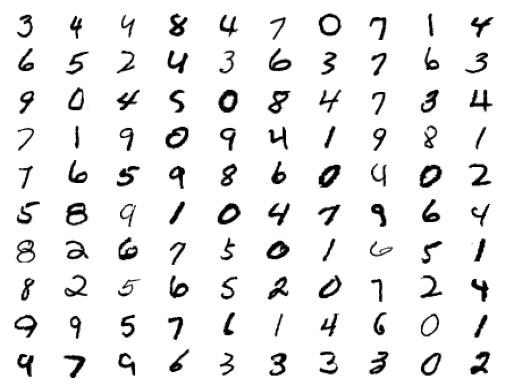

In [5]:
# Let's have a look at some of these hand written digits!

figure = plt.figure()
num_of_images = 100
# Randomly sample which digits to show (instead of just the first 100)
sample_indices = torch.randperm(len(x_train))[:num_of_images]
for index, sample in enumerate(sample_indices, start=1):
    plt.subplot(10, 10, index)
    plt.axis('off')
    plt.imshow(x_train[sample], cmap='gray_r')
plt.show()

### Warm-up: telling just two digits apart (0 vs 1)

Before tackling all ten digits, let's see how a tiny "network" with a single bottleneck node (`784 -> 1 -> ...`)  does on an *easier* job: classifying only **0s and 1s** (using a custom subset that we built above - `x_train_zero_one` / `y_train_zero_one`).

A single neuron squeezes the whole image down to **one number**. For *two* classes that's actually enough -- the model just needs that number to land one way for a 0 and the other way for a 1. 

When you run the cell, you'll see a couple different ways of vidualizing all the connections being made by the model.

Every time we run this, we'll print out an example where the model **failed**, so we can see an example of something we've missed, and decide how annoyed to be about it)

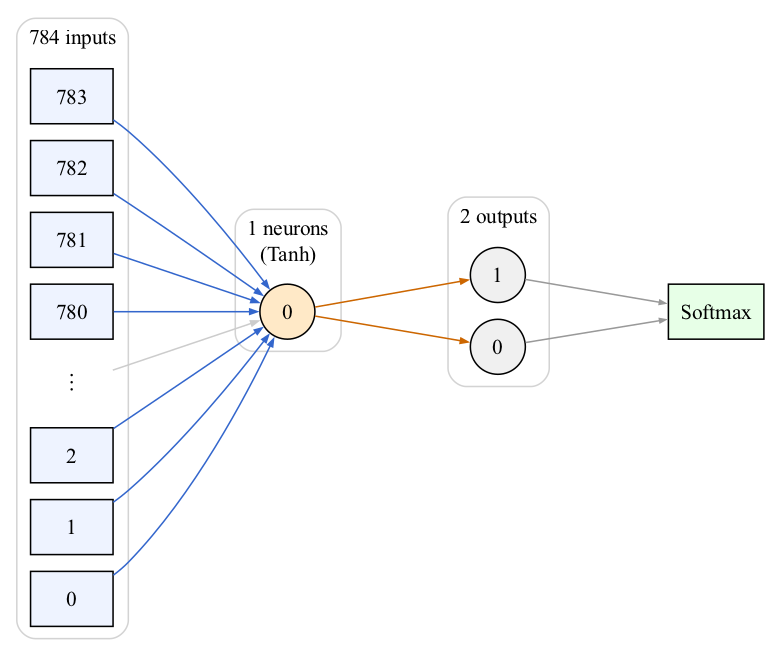

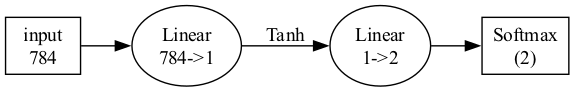

Starting accuracy: 53.66%
progress: 0.00%  loss: 0.28204888105392456
progress: 20.00%  loss: 0.019372660666704178
progress: 40.00%  loss: 0.006214680150151253
progress: 60.00%  loss: 0.002811732469126582
progress: 80.00%  loss: 0.0014375601895153522
Ending accuracy: 99.86%
Target: 0 Predicted: 1


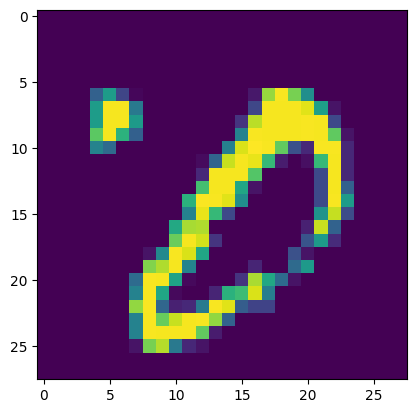

In [6]:
batch_size = 32
steps = 5000
learning_rate = 0.001
loss_function = nn.MSELoss()
checkin = int(steps / 5)

# Same 784 -> 1 bottleneck as before, but now only TWO output labels (0 vs 1)
model = nn.Sequential(nn.Flatten(),
                      nn.Linear(28*28, 1),
                      nn.Tanh(),
                      nn.Linear(1, 2),
                      nn.Softmax(dim=-1))

# Picture the network
draw_funnel(model, out_labels=[0, 1])
draw_model(model)

acc = test_accuracy(x_test_zero_one, y_test_zero_one, model)
print("Starting accuracy: {:.2%}".format(acc))

train_with_data(x_train_zero_one, y_train_zero_one,
                model, batch_size, steps,
                learning_rate, loss_function, checkin=checkin)

acc = test_accuracy(x_test_zero_one, y_test_zero_one, model)
print("Ending accuracy: {:.2%}".format(acc))

# Show a random failure or two (there are usually only a handful)
_ = test_accuracy(x_test_zero_one, y_test_zero_one, model, show_failures=1, class_labels=[0, 1])

### A harder warm-up: 4 vs 9

0s and 1s are easy -- they barely look alike. Let's hand the *same* single-neuron bottleneck a tougher pair: **4s and 9s**, which are genuinely easy to confuse. The model is identical (`784 -> 1 -> 2`); only the dataset changes (`x_train_four_nine` / `y_train_four_nine`).

Watch how the ending accuracy compares to the 0-vs-1 case. Squeezing the whole image down to a single number is much harder when the two digits actually resemble each other -- so expect more failures here.

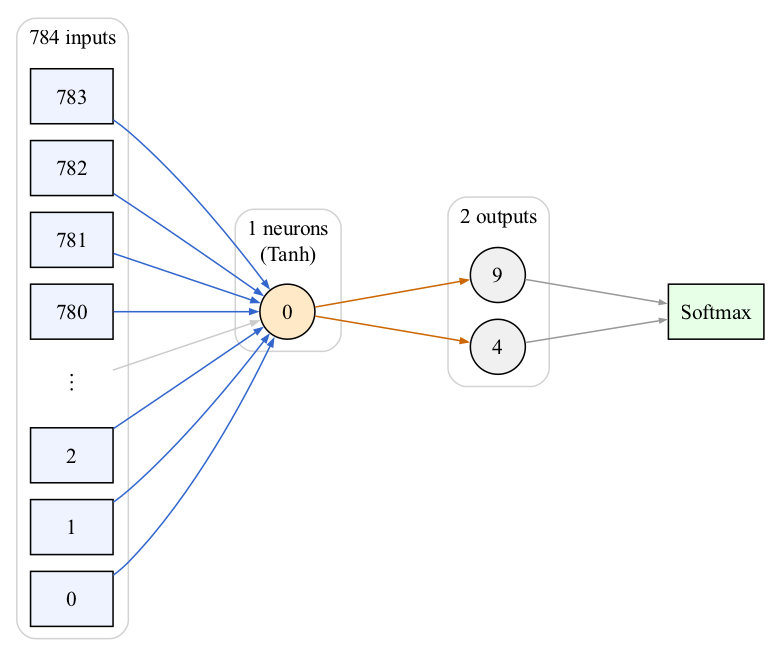

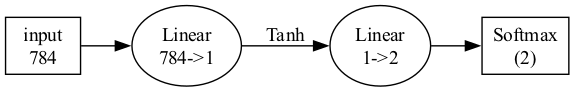

Starting accuracy: 49.32%
progress: 0.00%  loss: 0.267148494720459
progress: 20.00%  loss: 0.042938243597745895
progress: 40.00%  loss: 0.007075238972902298
progress: 60.00%  loss: 0.0033780583180487156
progress: 80.00%  loss: 0.04522492364048958
Ending accuracy: 97.29%
Target: 9 Predicted: 4


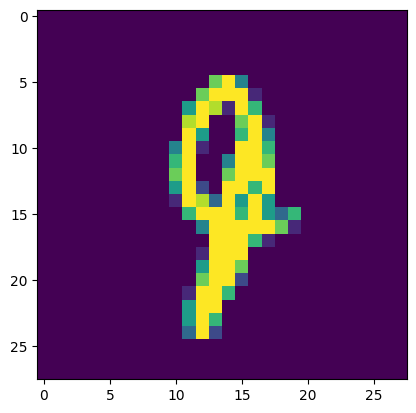

In [7]:
batch_size = 32
steps = 5000
learning_rate = 0.001
loss_function = nn.MSELoss()
checkin = int(steps / 5)

# Same 784 -> 1 bottleneck, now telling 4s from 9s (a much harder pair than 0 vs 1)
model = nn.Sequential(nn.Flatten(),
                      nn.Linear(28*28, 1),
                      nn.Tanh(),
                      nn.Linear(1, 2),
                      nn.Softmax(dim=-1))

# Picture the network
#draw_funnel(model, out_labels=[4, 9])
draw_model(model)

acc = test_accuracy(x_test_four_nine, y_test_four_nine, model)
print("Starting accuracy: {:.2%}".format(acc))

train_with_data(x_train_four_nine, y_train_four_nine,
                model, batch_size, steps,
                learning_rate, loss_function, checkin=checkin)

acc = test_accuracy(x_test_four_nine, y_test_four_nine, model)
print("Ending accuracy: {:.2%}".format(acc))

# Show a random failure or two
_ = test_accuracy(x_test_four_nine, y_test_four_nine, model, show_failures=1, class_labels=[4, 9])

**Training on the entire trainset**

---
Now let's think bigger. We want to just predict which digit is written out of **all** digits 0-9. 

That approach of connecting 784 inputs to a single neuron worked for the binary case. It's awful for multiple classes. Really bad. 

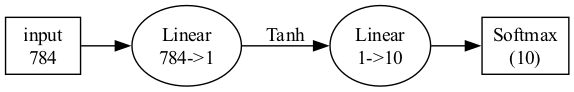

Starting accuracy: 8.68%
progress: 0.00%  loss: 0.10396569967269897
progress: 20.00%  loss: 0.08040520548820496
progress: 40.00%  loss: 0.08852393925189972
progress: 60.00%  loss: 0.08050179481506348
progress: 80.00%  loss: 0.08324059098958969
Ending accuracy: 20.98%
Target: 3 Predicted: 1


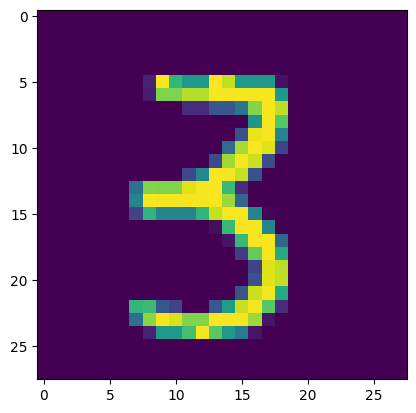

In [10]:

batch_size = 32 # How many images we train on at every step
steps = 20000 # How many total steps we will train for
learning_rate = 0.001 # How fast we adjust gradients with gradient descent
loss_function = nn.MSELoss() # Which loss function we're using
checkin = int(steps / 5) # How often we print our loss (smaller = more frequently)

# Change this model to change try and improve results
model = nn.Sequential(nn.Flatten(), # <--- the model needs to begin with this
                      nn.Linear(28*28, 1), # <--- the first argument to this Linear() function must be 28*28 (or 784)
                      nn.Tanh(),
                      nn.Linear(1, 10), # <--- the last argument to this Linear() function must be 10
                      nn.Softmax(dim=-1)) # <--- the model needs to end with this

# Draw two pictures of this network:
#   draw_funnel - shows every value funneling through the layers
#   draw_model  - shows the simpler one-box-per-layer summary
draw_funnel(model)
draw_model(model)

# Here we get a starting testing accuracy
acc = test_accuracy(x_test, y_test, model)
print("Starting accuracy: {:.2%}".format(acc))

# Train our model with our train_with_data helper function
train_with_data(x_train, y_train,
                model, batch_size, steps,
                learning_rate, loss_function, checkin=checkin)

# Check the ending testing accuracy
acc = test_accuracy(x_test, y_test, model)
print("Ending accuracy: {:.2%}".format(acc))

# Show some random failed predictions
_ = test_accuracy(x_test, y_test, model, show_failures=1) 
# Change this to change how many failures are shown    ^

We should do something better.  Below, I've used two neurons. That's better, but not good.  Let's try to make the model more complicated.

What needs to stay the same: 
- The first layer of the model (nn.Flatten()))
- In the first Linear() layer, the first argument must be 28*28 (or 784)
- In the last Linear() layer, the last argument must be 10
- The last layer (nn.Softmax()).

Also: Consecutive Linear layers must "fit":  e.g. 
```		    
nn.Linear(28*28, 2),        # the final dimension of this line ...
nn.ReLU(),                    #        ,----------------------'
nn.Linear(2, 10),           # <-----/  must match the first dimension in this line
```    
 
Everything else can change! Some ways you might try to make improvements:
1.   Making the network deeper (more layers).
2.   Making the network wider (more neurons).
3.   Try bigger and smaller batch sizes.
4.   Try more/fewer steps.
5.   Using different activation functions (replacing nn.Tanh) such as nn.Sigmoid(), nn.ReLU(), nn.ELU(). a complete list of activation functions can be found at https://pytorch.org/docs/stable/nn.html#non-linear-activations-weighted-sum-nonlinearity. 


Feel free to change any of the code in the cell. You might want to make a copy of the code, so you can start over with a clean slate; you may also want to make copies of the code cell, so you can see multiple results.

Also feel free to use any of the tools in the nn library: https://pytorch.org/docs/stable/nn.html

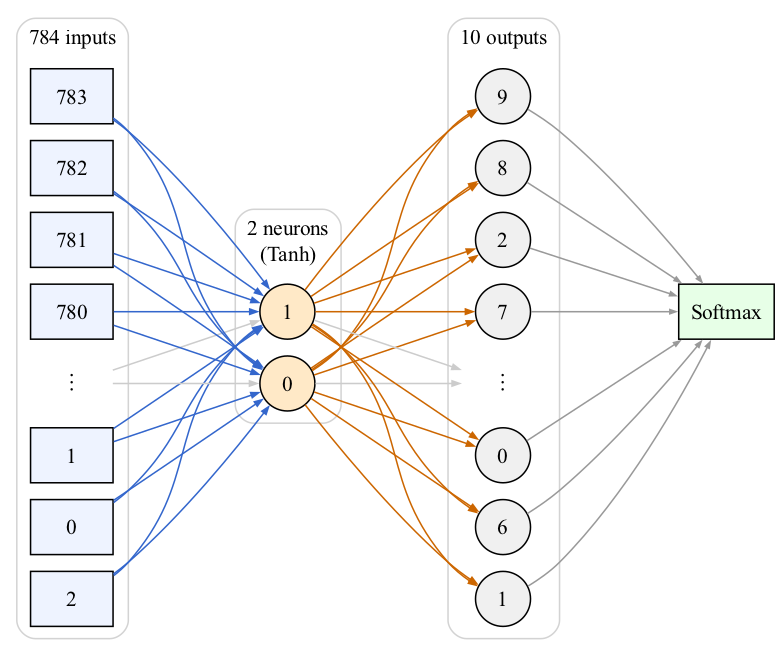

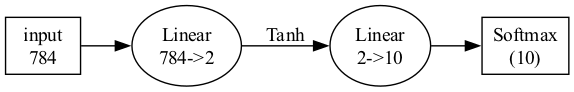

Starting accuracy: 10.39%
progress: 0.00%  loss: 0.09142838418483734
progress: 20.00%  loss: 0.07177920639514923
progress: 40.00%  loss: 0.07437534630298615
progress: 60.00%  loss: 0.052282076328992844
progress: 80.00%  loss: 0.06740614026784897
Ending accuracy: 48.57%
Target: 5 Predicted: 4


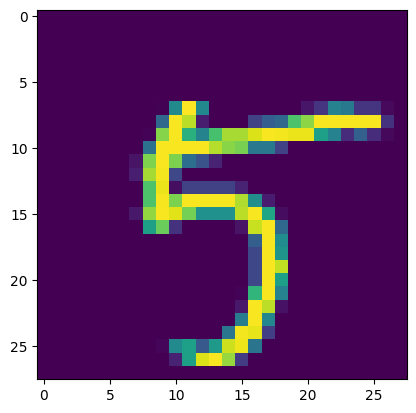

In [19]:
batch_size = 32 # How many images we train on at every step
steps = 20000 # How many total steps we will train for
learning_rate = 0.001 # How fast we adjust gradients with gradient descent
loss_function = nn.MSELoss() # Which loss function we're using
checkin = int(steps / 5) # How often we print our loss (smaller = more frequently)

# Change this model to change try and improve results
model = nn.Sequential(nn.Flatten(), # <--- the model needs to begin with this
                      nn.Linear(28*28, 2), # <--- the first argument to this Linear() function must be 28*28 (or 784)
                      nn.Tanh(),
                      nn.Linear(2, 10), # <--- the last argument to this Linear() function must be 10
                      nn.Softmax(dim=-1)) # <--- the model needs to end with this

# Draw two pictures of this network:
#   draw_funnel - shows every value funneling through the layers
#   draw_model  - shows the simpler one-box-per-layer summary
draw_funnel(model)
draw_model(model)

# Here we get a starting testing accuracy
acc = test_accuracy(x_test, y_test, model)
print("Starting accuracy: {:.2%}".format(acc))

# Train our model with our train_with_data helper function
train_with_data(x_train, y_train,
                model, batch_size, steps,
                learning_rate, loss_function, checkin=checkin)

# Check the ending testing accuracy
acc = test_accuracy(x_test, y_test, model)
print("Ending accuracy: {:.2%}".format(acc))

# Show some random failed predictions
_ = test_accuracy(x_test, y_test, model, show_failures=1) 
# Change this to change how many failures are shown    ^

**Training on a small trainset**

---

In the previous cells, we were training on a big dataset (60,000 images - the entire MNIST training set ... which is not really THAT big).

Deep learning is harder when we have a smaller dataset to work with. Below we're going to try to build a model that can learn using only 500 images. Feel free to change anything in the cell below

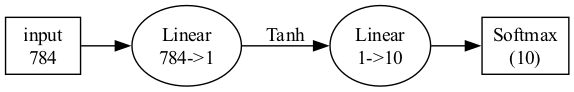

Starting accuracy: 12.29%
progress: 0.00%  loss: 0.08921460062265396
progress: 20.00%  loss: 0.07679720968008041
progress: 40.00%  loss: 0.07123816758394241
progress: 60.00%  loss: 0.06720413267612457
progress: 80.00%  loss: 0.06913315504789352
Ending accuracy: 21.40%
Target: 5 Predicted: 8


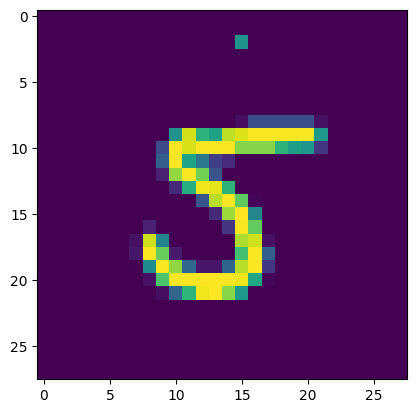

In [11]:

batch_size = 32 # How many images we train on at every step
steps = 20000 # How many total steps we will train for
learning_rate = 0.001 # How fast we adjust gradients with gradient descent
loss_function = nn.MSELoss() # Which loss function we're using
checkin = int(steps / 5) # How often we print our loss (smaller = more frequently)

# Change this model to change try and improve results
model = nn.Sequential(nn.Flatten(), # <--- the model needs to begin with this
                      nn.Linear(28*28, 1), 
                      nn.Tanh(),
                      nn.Linear(1, 10), 
                      nn.Softmax(dim=-1)) # <--- the model needs to end with this

# Draw a picture of this network
draw_model(model)


# Here we get a starting testing accuracy
acc = test_accuracy(x_test, y_test, model)
print("Starting accuracy: {:.2%}".format(acc))

# Train our model with our train_with_data helper function
train_with_data(x_small, y_small,
                model, batch_size, steps,
                learning_rate, loss_function, checkin=checkin)

# Check the ending testing accuracy
acc = test_accuracy(x_test, y_test, model)
print("Ending accuracy: {:.2%}".format(acc))

# Show some random failed predictions
_ = test_accuracy(x_test, y_test, model, show_failures=1) 
# Change this to change how many failures are shown    ^